In [15]:
database = "Qin" # MGnify / IGC / Qin
grouping = "Groups" # Groups / Subgroups
new_discovery_study = "Werner" # ValdesMas / Werner
file_prefix = database +"_"+grouping + "_" + new_discovery_study + "_"
print(file_prefix)

Qin_Groups_Werner_


In [16]:
# load the different permanova results
import re
#import glob
import pandas as pd

def extract_permanova_stats(filepath):
    with open(filepath, 'r') as f:
        content = f.read()
    
    # Finds "Permanova (XYZ)" followed by "test statistic    <Float>"
    pattern = r"Permanova \(([^)]+)\).*?test statistic\s+([\d.]+)"
    matches = re.findall(pattern, content, re.DOTALL)
    
    return {name: float(value) for name, value in matches}

f_study = []
f_disease = []

### all metaproteins
all_mp = extract_permanova_stats(str("Permanova_Results_Revision_"+file_prefix+"_all_metaproteins.txt"))
f_study.append(all_mp["Study"])
f_disease.append(all_mp["Disease"])

### shared metaproteins
shared_mp = extract_permanova_stats(str("Permanova_Results_Revision_"+file_prefix+"_shared_metaproteins.txt"))
f_study.append(shared_mp["Study"])
f_disease.append(shared_mp["Disease"])

### shared metaproteins (MMUPHin corrected)
shared_mp_MMUPHin = extract_permanova_stats(str("Permanova_Results_Revision_"+file_prefix+"_shared_metaproteins_MMUPHIN_corrected.txt"))
f_study.append(shared_mp_MMUPHin["Study"])
f_disease.append(shared_mp_MMUPHin["Disease"])

### selected metaproteins (MMUPHin corrected)
selected_mp_MMUPHin = extract_permanova_stats(str("Permanova_Results_Revision_"+file_prefix+"_selected_metaproteins_MMUPHIN_corrected.txt"))
f_study.append(selected_mp_MMUPHin["Study"])
f_disease.append(selected_mp_MMUPHin["Disease"])

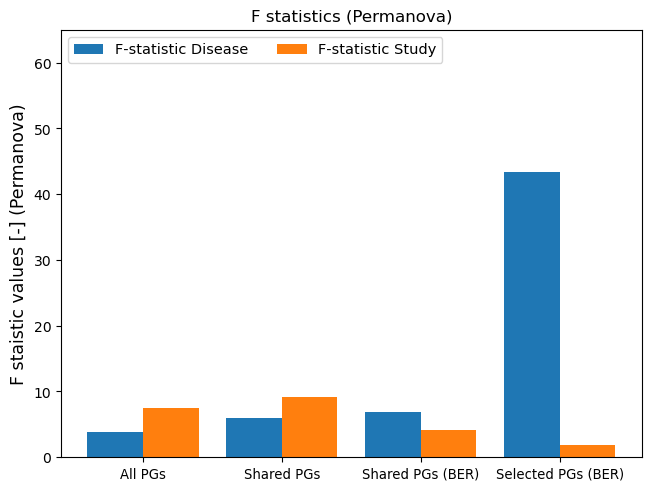

In [17]:
import matplotlib.pyplot as plt
import numpy as np

category = ["All PGs","Shared PGs", "Shared PGs (BER)", "Selected PGs (BER)"]
f_statistics = {
    'F-statistic Disease': f_disease,
    'F-statistic Study': f_study,
}

x = np.arange(len(category))  # the label locations
width = 0.4  # the width of the bars
multiplier = 0.5

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in f_statistics.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    #ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('F staistic values [-] (Permanova)', fontsize = 12.5)
ax.set_title('F statistics (Permanova)')
ax.set_xticks(x + width, category, fontsize = 9.5)
ax.legend(loc='upper left', ncols=2,fontsize = 10.5)
ax.set_ylim(0, 65)
plt.savefig(file_prefix + "SupplementaryFigure4.png")
plt.show()